# Solve ILRS problem using Gurobi PoolSearch 

In [1]:
from solve_gurobi_poolsearch_funcs import * 

In [ ]:
# Build and solve the model using Gurobi's PoolSearch feature

# Set up paths
script_dir = Path().parent
data_filepath = script_dir / ".." / "data"
result_dir = script_dir / "result_gurobi"

# Build model
m_poolsearch, vars_poolsearch = build_discrete_ip_model(
    str(data_filepath), 
    use_quad_constraints=True
)

# Solve with pool search
result_dict = solve_gurobi_pool(
    m=m_poolsearch,
    vars_dict=vars_poolsearch,
    pool_search_mode=2,
    pool_solutions=100,
    output_dir=result_dir,
    verbose=True,
    save=True
)


# Import Gurobi PoolSearch Run for Analysis

In [ ]:
# Load data
import_dir = './result_gurobi'
gpool_path = os.path.join(import_dir, 'ilrs_gpool_n228_20260126_101442.json')

gpool_data = load_gurobi_pool_results(gpool_path)
run_info = gpool_data['run_info']
solutions = gpool_data['solutions']

# Print run info
print(f"Loaded {len(solutions)} solutions\n")
print_run_info(run_info)

# # Create flattened DataFrame
gpool_flat = create_flattened_dataframe(solutions)

print(f"\nFlattened DataFrame shape: {gpool_flat.shape}")
print(f"Columns: {list(gpool_flat.columns)}")

# Group by objective value
obj_groups = group_by_objective(gpool_flat)

print(f"Number of unique objective values: {len(obj_groups)}")

Loaded 228 solutions

Run Info:
  Model: objective
  Variables: 24
  Constraints: 38
  Solve Time: 62.95 seconds
  Solutions Found: 228

Flattened DataFrame shape: (228, 26)
Columns: ['solution_id', 'ip_obj_value', 'y_r1', 'y_r2', 'y_s1', 'y_s2', 'y_s3', 'w_1_1', 'w_1_2', 'w_2_1', 'w_2_2', 'f_srce_r1', 'f_srce_r2', 'f_s1_sink', 'f_s2_sink', 'f_s3_sink', 'f_r1_s1', 'f_r1_s2', 'f_r1_s3', 'f_r2_s1', 'f_r2_s2', 'f_r2_s3', 'z_cat_1', 'z_cat_2', 'z_an_1', 'z_an_2']
Number of unique objective values: 78


In [22]:
# Analyze solutions to distinguish duplicates vs same objective
print_solution_analysis(gpool_flat)



SOLUTION ANALYSIS

1. DUPLICATE SOLUTIONS (same y/z variable values AND same objective):
   Total solutions with duplicate y/z variable combinations: 159
   Unique y/z variable combinations: 69

   Duplicate groups (same y/z variables, same objective):
     Objective 45.26: 7 solutions (IDs: [66, 67, 68, 69, 70, 71, 72])
     Objective 45.40: 7 solutions (IDs: [74, 75, 76, 77, 78, 79, 80])
     Objective 45.46: 7 solutions (IDs: [81, 82, 83, 84, 85, 86, 87])
     Objective 45.64: 7 solutions (IDs: [90, 91, 92, 93, 94, 95, 96])
     Objective 46.02: 7 solutions (IDs: [97, 98, 99, 100, 101, 102, 103])
     Objective 46.08: 7 solutions (IDs: [104, 105, 106, 107, 108, 109, 110])
     Objective 46.24: 7 solutions (IDs: [111, 112, 113, 114, 115, 116, 117])
     Objective 46.32: 7 solutions (IDs: [118, 119, 120, 121, 122, 123, 124])
     Objective 47.64: 7 solutions (IDs: [125, 126, 127, 128, 129, 130, 131])
     Objective 47.80: 7 solutions (IDs: [132, 133, 134, 135, 136, 137, 138])
     Ob

{'analysis': {'duplicate_solutions': {47.8: {'count': 7,
    'solution_ids': [132, 133, 134, 135, 136, 137, 138],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0)},
   48.02: {'count': 7,
    'solution_ids': [139, 140, 141, 142, 143, 144, 145],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0)},
   47.64: {'count': 7,
    'solution_ids': [125, 126, 127, 128, 129, 130, 131],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0)},
   48.08: {'count': 7,
    'solution_ids': [146, 147, 148, 149, 150, 151, 152],
    'variable_signature': (1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0)},
   46.32: {'count': 7,
    'solution_ids': [118, 119, 120, 121, 122, 123, 124],
    'variable_signature': (1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0)},
   46.08: {'count': 7,
    'solution_ids': [104, 105, 106, 107, 108, 109, 110],
    'variable_signature': (1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0)},
   46.02: {'count': 7,
    'solution_ids':

### Plot (# Solutions Found) vs (# PoolSearch Solution Count Setpoint)

,n,solve_time,solution_count
0,100,25.426827,100
1,150,36.264453,150
2,200,56.030090,200
3,220,54.346291,220
4,225,53.913728,225
5,227,60.812411,227
6,228,62.953803,228
7,230,54.486437,230
8,231,54.102281,231
9,232,53.312682,232


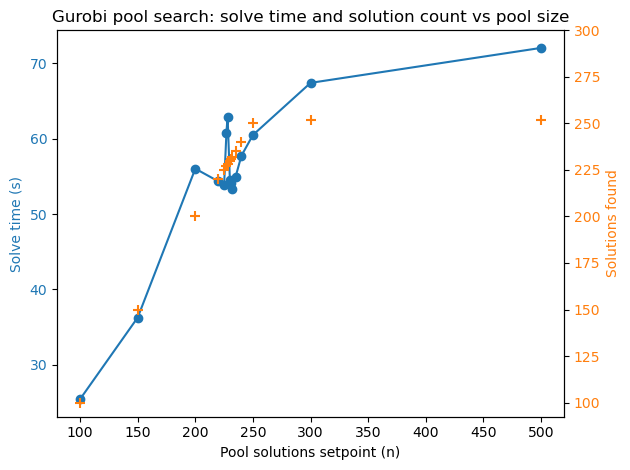

In [23]:
# Solution time vs pool-solutions setpoint (from result_gurobi ilrs_gpool_n*.json)
import matplotlib.pyplot as plt

df = aggregate_pool_run_timings()
display(df)

fig, ax1 = plt.subplots()
ax1.plot(df["n"], df["solve_time"], "o-", markersize=6, color="C0")
ax1.set_xlabel("Pool solutions setpoint (n)")
ax1.set_ylabel("Solve time (s)", color="C0")
ax1.tick_params(axis="y", labelcolor="C0")

ax2 = ax1.twinx()
ax2.scatter(df["n"], df["solution_count"], marker="+", s=50, color="C1", zorder=5)
ax2.set_ylabel("Solutions found", color="C1")
ax2.set_ylim(top=300)
ax2.tick_params(axis="y", labelcolor="C1")

plt.title("Gurobi pool search: solve time and solution count vs pool size")
fig.tight_layout()
plt.show()